# EDA - Processed Data
Esse notebook aplica uma EDA mais completa sobre `data/processed/offer_instances_final.parquet`, o dataset unificado gerado no processamento (notebook 04 / `src/data/process_raw.py`). O objetivo aqui e entender a fundo o comportamento do target `success`, validar decisoes de processamento, e levantar evidencias que vao orientar a etapa de feature engineering e modelagem.

In [2]:
from pyspark.sql import SparkSession, Window
import pyspark.sql.functions as F
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Sessao Spark
spark = SparkSession.builder.appName("ifood-case").getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
/mnt/HD2/Data_Science/ifood-case/.venv/lib/python3.12/site-packages/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/07/25 18:22:54 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [4]:
# Leitura do dataset processado
offer_instances = spark.read.parquet("../data/processed/offer_instances_final.parquet")

In [4]:
# Schema do dataset processado
offer_instances.printSchema()

root
 |-- account_id: string (nullable = true)
 |-- offer_id: string (nullable = true)
 |-- offer_type: string (nullable = true)
 |-- channels: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- discount_value: long (nullable = true)
 |-- min_value: long (nullable = true)
 |-- duration: double (nullable = true)
 |-- received_time: double (nullable = true)
 |-- viewed_time: double (nullable = true)
 |-- completed_time: double (nullable = true)
 |-- window_end: double (nullable = true)
 |-- reward: double (nullable = true)
 |-- has_post_view_transaction: boolean (nullable = true)
 |-- success: integer (nullable = true)
 |-- age: long (nullable = true)
 |-- gender: string (nullable = true)
 |-- credit_card_limit: double (nullable = true)
 |-- registered_on: date (nullable = true)



In [5]:
print(
    f"Quantidade de linhas: {offer_instances.count()}; Quantidade de colunas: {len(offer_instances.columns)}"
)

Quantidade de linhas: 63288; Quantidade de colunas: 18


In [6]:
# Taxa de sucesso geral (baseline)
offer_instances.select(F.avg("success").alias("success_rate_geral")).show()

+------------------+
|success_rate_geral|
+------------------+
| 0.389252306914423|
+------------------+



**Validacao do step 3.1:**
1. O schema bate exatamente com as 18 colunas selecionadas no processamento (notebook 04, step 2.9), incluindo `channels` como array e `registered_on` como date.
2. `63288` linhas, igual ao total validado no processamento.
3. Taxa de sucesso geral = `0.3893` (~38.9%). Conferindo: a media ponderada das taxas por `offer_type` encontradas no processamento (discount 0.4163 * 25316 + informational 0.3869 * 12651 + bogo 0.3634 * 25321) / 63288 = 0.3892, batendo com o valor observado aqui. Ou seja, a leitura do parquet preservou os dados do processamento sem distorcao.

## 3.2 - Auditoria de valores nulos
Vamos conferir se os nulos presentes no dataset processado fazem sentido, dado que ja sabiamos de alguns deles desde as EDAs em dados brutos (nulos de cadastro incompleto em `profile`, e nulos esperados de `viewed_time`/`completed_time`/`reward` quando a oferta nao foi vista/completada).

In [7]:
# Contagem de nulos por coluna
offer_instances.select(
    [F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in offer_instances.columns]
).show()

+----------+--------+----------+--------+--------------+---------+--------+-------------+-----------+--------------+----------+------+-------------------------+-------+----+------+-----------------+-------------+
|account_id|offer_id|offer_type|channels|discount_value|min_value|duration|received_time|viewed_time|completed_time|window_end|reward|has_post_view_transaction|success| age|gender|credit_card_limit|registered_on|
+----------+--------+----------+--------+--------------+---------+--------+-------------+-----------+--------------+----------+------+-------------------------+-------+----+------+-----------------+-------------+
|         0|       0|         0|       0|             0|        0|       0|            0|      15990|         35500|         0| 35500|                        0|      0|8066|  8066|             8066|            0|
+----------+--------+----------+--------+--------------+---------+--------+-------------+-----------+--------------+----------+------+--------------

In [8]:
# Nulos de "age", "gender" e "credit_card_limit" deveriam ser o mesmo grupo de clientes com cadastro
# incompleto (visto na EDA 02). Vamos conferir se a contagem de nulos bate entre as tres colunas.
offer_instances.filter(
    F.col("age").isNull()
    & F.col("gender").isNull()
    & F.col("credit_card_limit").isNull()
).count()

8066

In [9]:
# Nulos de "viewed_time", "completed_time" e "reward" por "offer_type".
# Esperado: "informational" nunca tem "completed_time"/"reward" preenchido, pois esse tipo de oferta
# nao gera evento "offer completed" (visto na EDA 01 e no processamento).
offer_instances.groupBy("offer_type").agg(
    F.count(F.col("viewed_time")).alias("viewed_time_nao_nulo"),
    F.count(F.col("completed_time")).alias("completed_time_nao_nulo"),
    F.count(F.col("reward")).alias("reward_nao_nulo"),
    F.count("*").alias("total"),
).show(truncate=False)

+-------------+--------------------+-----------------------+---------------+-----+
|offer_type   |viewed_time_nao_nulo|completed_time_nao_nulo|reward_nao_nulo|total|
+-------------+--------------------+-----------------------+---------------+-----+
|discount     |17950               |14878                  |14878          |25316|
|informational|8254                |0                      |0              |12651|
|bogo         |21094               |12910                  |12910          |25321|
+-------------+--------------------+-----------------------+---------------+-----+



In [10]:
# Confirmando que "reward" so e nulo quando "completed_time" tambem e nulo (reward so existe quando a
# oferta foi de fato completada). Se esse count for 0, a relacao esta consistente.
offer_instances.filter(
    F.col("completed_time").isNull() != F.col("reward").isNull()
).count()

0

**Conclusoes do step 3.2:**
1. `age`/`gender`/`credit_card_limit` tem exatamente `8066` nulos cada, todos no mesmo grupo de linhas. Isso bate com a proporcao de cadastros incompletos vista na EDA 02 (2175/17000 = 12.79% dos clientes), ja que 8066/63288 = 12.74% das instancias de oferta - a pequena diferenca e esperada, pois clientes com cadastro incompleto nao recebem necessariamente a mesma quantidade de ofertas que a media.
2. `viewed_time` nulo em `15990` linhas (oferta recebida mas nunca vista) - nao ha nenhuma surpresa aqui, e coerente com o funil decrescente visto na EDA 03 (received > viewed > completed).
3. `completed_time` e `reward` sao nulos exatamente juntos (diferenca = 0 linhas), confirmando que `reward` so e preenchido quando a oferta e de fato completada.
4. Como esperado, `informational` tem `completed_time`/`reward` sempre nulos (0 nao-nulos em 12651 linhas) - esse tipo de oferta nunca gera evento `offer completed`, entao o sucesso dela depende exclusivamente de `has_post_view_transaction`.
5. Nenhum nulo inesperado encontrado. Auditoria de nulos aprovada.

## 3.3 - Taxa de sucesso por "offer_type" e por canal
Vamos revalidar a taxa de sucesso por `offer_type` diretamente no dataset processado (deve bater com o processamento em 04) e, em seguida, explodir `channels` para ver se o mix de canais de veiculacao tem alguma relacao com o sucesso.

In [11]:
# Taxa de sucesso por "offer_type"
# Deve bater com o que ja tinhamos visto no processamento (04): discount > informational > bogo.
offer_instances.groupBy("offer_type").agg(
    F.avg("success").alias("taxa_sucesso"), F.count("*").alias("total")
).orderBy(F.desc("taxa_sucesso")).show(truncate=False)

+-------------+-------------------+-----+
|offer_type   |taxa_sucesso       |total|
+-------------+-------------------+-----+
|discount     |0.41629799336388057|25316|
|informational|0.38692593470871867|12651|
|bogo         |0.36337427431776   |25321|
+-------------+-------------------+-----+



/mnt/HD2/Data_Science/ifood-case/.venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


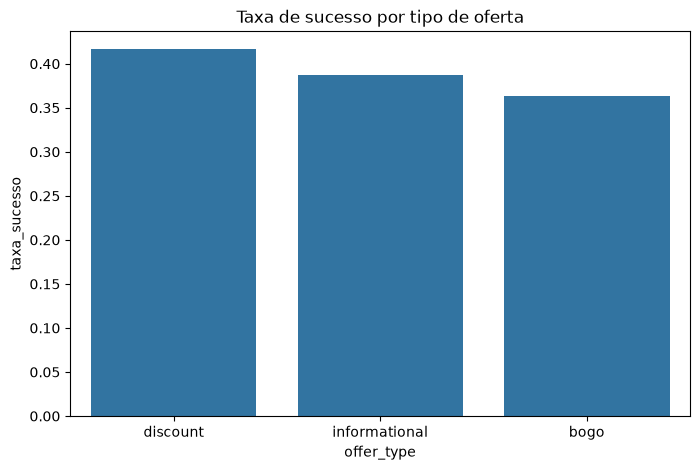

In [12]:
# Grafico de barras da taxa de sucesso por "offer_type"
success_by_type = (
    offer_instances.groupBy("offer_type")
    .agg(F.avg("success").alias("taxa_sucesso"))
    .toPandas()
)
plt.figure(figsize=(8, 5))
sns.barplot(
    data=success_by_type,
    x="offer_type",
    y="taxa_sucesso",
    order=success_by_type.sort_values("taxa_sucesso", ascending=False)["offer_type"],
)
plt.title("Taxa de sucesso por tipo de oferta")
plt.show();

In [13]:
# Taxa de sucesso por canal (explodindo "channels", ja que uma oferta pode ter varios canais).
# Atencao: uma mesma instancia de oferta e contada em mais de um canal aqui (nao e mutuamente exclusivo).
offer_instances.withColumn("channel", F.explode("channels")).groupBy("channel").agg(
    F.avg("success").alias("taxa_sucesso"), F.count("*").alias("total")
).orderBy(F.desc("taxa_sucesso")).show(truncate=False)

+-------+-------------------+-----+
|channel|taxa_sucesso       |total|
+-------+-------------------+-----+
|social |0.4751864639063859 |37943|
|mobile |0.41249956074076677|56914|
|email  |0.389252306914423  |63288|
|web    |0.3841759892477369 |50594|
+-------+-------------------+-----+



In [14]:
# A taxa de sucesso por canal pode estar confundida com o mix de "offer_type" (ex: um canal pode
# aparecer mais em ofertas "bogo" do que em "discount"). Vamos abrir a taxa de sucesso por
# canal x offer_type para verificar se o canal ainda faz diferenca dentro de cada tipo de oferta.
offer_instances.withColumn("channel", F.explode("channels")).groupBy(
    "channel", "offer_type"
).agg(F.avg("success").alias("taxa_sucesso"), F.count("*").alias("total")).orderBy(
    "channel", F.desc("taxa_sucesso")
).show(truncate=False)

+-------+-------------+-------------------+-----+
|channel|offer_type   |taxa_sucesso       |total|
+-------+-------------+-------------------+-----+
|email  |discount     |0.41629799336388057|25316|
|email  |informational|0.38692593470871867|12651|
|email  |bogo         |0.36337427431776   |25321|
|mobile |discount     |0.49524865378523913|18942|
|mobile |informational|0.38692593470871867|12651|
|mobile |bogo         |0.36337427431776   |25321|
|social |discount     |0.6016433594058623 |12657|
|social |informational|0.47468354430379744|6320 |
|social |bogo         |0.39096277549298747|18966|
|web    |discount     |0.41629799336388057|25316|
|web    |bogo         |0.3696099646382013 |18947|
|web    |informational|0.29932080240088454|6331 |
+-------+-------------+-------------------+-----+



**Conclusoes do step 3.3:**
1. Taxa de sucesso por `offer_type` bate exatamente com o processamento (04): `discount` (0.4163) > `informational` (0.3869) > `bogo` (0.3634).
2. Por canal (agregado, ignorando `offer_type`): `social` se destaca bastante (0.4752), seguido de `mobile` (0.4125), `email` (0.3893, presente em 100% das ofertas) e `web` (0.3842).
3. **Atencao - possivel confundimento**: `channels` e um atributo do cadastro da oferta (`offers.json`), nao uma atribuicao aleatoria por envio/cliente. Ou seja, "taxa de sucesso por canal" na verdade reflete quais `offer_id`s especificos incluem aquele canal, e nao um efeito causal de canal isolado. Isso fica evidente ao abrir canal x `offer_type`: varias combinacoes tem taxa **identica** a de `email` (que esta presente em 100% das ofertas) - por exemplo `mobile`+`informational` e `mobile`+`bogo` sao identicas a `email`+`informational`/`email`+`bogo`, indicando que, para esses tipos, o subconjunto de ofertas com `mobile` e exatamente o mesmo subconjunto com `email` (nenhuma oferta tem um canal sem o outro, nesses casos).
4. Dentro de `discount` e `informational`, `social` aparece associado a taxas bem mais altas (0.60 e 0.47, respectivamente) mesmo comparando dentro do mesmo `offer_type` - um sinal mais confiavel de que o canal `social` pode estar de fato associado a ofertas/segmentos mais eficazes, mas ainda sujeito a confundimento por que ofertas especificas usam `social` (ex: pode ser um subconjunto de ofertas com melhores parametros de desconto).
5. Conclusao pratica: `channels` sera tratado como feature (nivel de oferta) na modelagem, mas nao deve ser interpretado como alavanca causal isolada sem mais investigacao (ex: nao temos como saber se enviar a mesma oferta por canais diferentes teria efeito diferente).

## 3.4 - Ranking de ofertas individuais (offer_id)
Ate agora olhamos apenas para o agregado por `offer_type`. Vamos abrir a granularidade para `offer_id` para identificar quais ofertas especificas performam melhor/pior - util como insight de negocio para a apresentacao final.

In [15]:
# Taxa de sucesso e volume por offer_id, incluindo metadados relevantes para interpretar o ranking
offer_ranking = (
    offer_instances.groupBy(
        "offer_id", "offer_type", "discount_value", "min_value", "duration"
    )
    .agg(F.avg("success").alias("taxa_sucesso"), F.count("*").alias("total"))
    .orderBy(F.desc("taxa_sucesso"))
)
offer_ranking.show(20, truncate=False)

+--------------------------------+-------------+--------------+---------+--------+-------------------+-----+
|offer_id                        |offer_type   |discount_value|min_value|duration|taxa_sucesso       |total|
+--------------------------------+-------------+--------------+---------+--------+-------------------+-----+
|fafdcd668e3743c1bb461111dcafc2a4|discount     |2             |10       |10.0    |0.6227100442198358 |6332 |
|2298d6c36e964ae4a3e7e9706d1fb8c2|discount     |3             |7        |7.0     |0.5805533596837945 |6325 |
|5a8bc65990b245e5a138643cd4eb9837|informational|0             |0        |3.0     |0.47468354430379744|6320 |
|f19421c1d4aa40978ebb69ca19b0e20d|bogo         |5             |5        |5.0     |0.4672628553177898 |6262 |
|4d5c57ea9a6940dd891ad53e9dbe8da0|bogo         |10            |10       |5.0     |0.36192733017377565|6330 |
|ae264e3637204a6fb9bb56bc8210ddfd|bogo         |10            |10       |7.0     |0.3448384060244744 |6374 |
|3f207df678b143eea3

/mnt/HD2/Data_Science/ifood-case/.venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


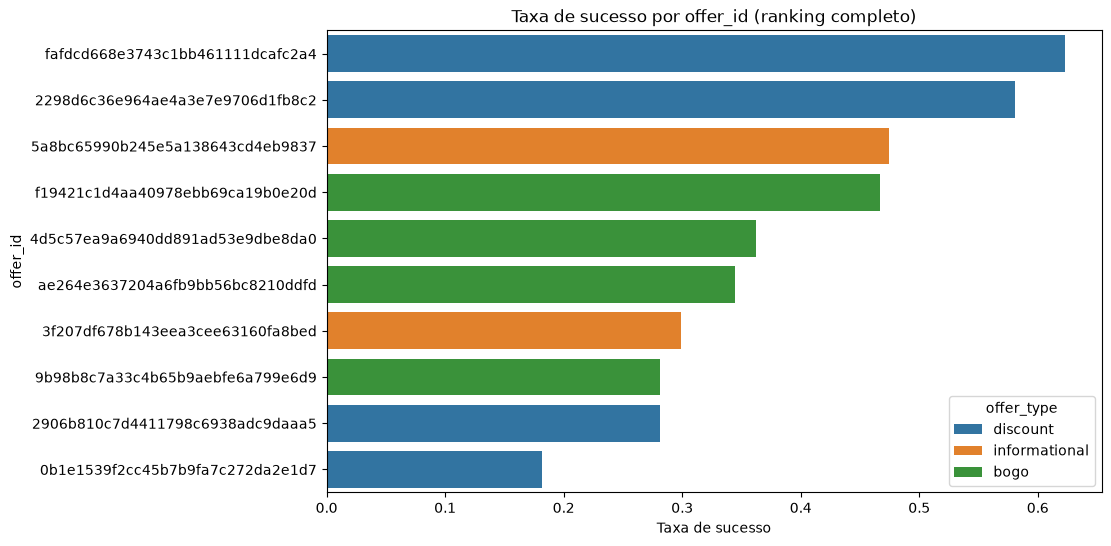

In [16]:
# Grafico de barras do ranking completo de ofertas (sao so 10 ofertas distintas no total, entao
# o "ranking" acaba sendo a lista inteira, nao apenas um top/bottom 10 recortado)
ranking_pd = offer_ranking.toPandas()
plt.figure(figsize=(10, 6))
sns.barplot(
    data=ranking_pd,
    x="taxa_sucesso",
    y="offer_id",
    hue="offer_type",
    order=ranking_pd.sort_values("taxa_sucesso", ascending=False)["offer_id"],
    dodge=False,
)
plt.title("Taxa de sucesso por offer_id (ranking completo)")
plt.xlabel("Taxa de sucesso")
plt.ylabel("offer_id")
plt.show();

**Conclusoes do step 3.4:**
1. Existem apenas **10 offer_id distintos** no total (confirmado pelo `offers.json` original - 4 discount, 4 bogo, 2 informational), entao o "ranking" mostrado acima ja e a lista completa, nao um recorte de top/bottom 10.
2. A oferta com melhor performance (`fafdcd66...`, discount, taxa 0.6227) tem `min_value=10` e `discount_value=2` (baixo valor minimo de compra, desconto pequeno, duracao longa de 10 dias) - barreira de entrada baixa parece favorecer conversao.
3. A pior oferta (`0b1e1539...`, discount, taxa 0.1817) tem `min_value=20`, o maior valor minimo entre todas as ofertas de discount, com `discount_value=5` - reforca a hipotese de que `min_value` alto reduz bastante a chance de sucesso.
4. Dentro de `bogo`, a oferta com `duration=5` e `discount_value=5`/`min_value=5` (`f19421c1...`, 0.4673) supera as demais `bogo` com `min_value=10` - sugere que, mesmo dentro do mesmo tipo, exigencias menores de valor minimo tendem a converter mais.
5. As duas ofertas `informational` ficam em posicoes intermediarias (0.4747 e 0.2993), com a de maior duracao (4 dias) performando pior que a de duracao menor (3 dias) - contraintuitivo a primeira vista, mas pode reflentir diferencas de canal/segmento de envio, nao so a duracao isolada.
6. Esse ranking reforca o valor de tratar `min_value`, `discount_value` e `duration` como features continuas na modelagem (alem de `offer_type` categorico), ja que ha variacao relevante de performance dentro do mesmo tipo de oferta.

## 3.5 - Economia da oferta vs sucesso
Como visto no 3.4, ha so 10 ofertas distintas, entao os atributos economicos (`discount_value`, `min_value`, `duration`) tem poucos valores unicos - um boxplot tradicional por valor individual teria pouco sentido. Em vez disso, vamos olhar a relacao entre esses atributos (incluindo `generosity`, ja usada na EDA 01) e a taxa de sucesso a nivel de oferta, usando o `offer_ranking` calculado no 3.4.

In [17]:
# Adicionando "generosity" (discount_value / min_value, nulo quando min_value=0, ou seja, sempre nulo
# para "informational") ao ranking de ofertas
ranking_pd = offer_ranking.withColumn(
    "generosity",
    F.when(F.col("min_value") == 0, None).otherwise(
        F.col("discount_value") / F.col("min_value")
    ),
).toPandas()
ranking_pd

/mnt/HD2/Data_Science/ifood-case/.venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


,offer_id,offer_type,discount_value,min_value,duration,taxa_sucesso,total,generosity
0,fafdcd668e3743c1bb461111dcafc2a4,discount,2,10,10.0,0.622710,6332,0.200000
1,2298d6c36e964ae4a3e7e9706d1fb8c2,discount,3,7,7.0,0.580553,6325,0.428571
2,5a8bc65990b245e5a138643cd4eb9837,informational,0,0,3.0,0.474684,6320,NaN
3,f19421c1d4aa40978ebb69ca19b0e20d,bogo,5,5,5.0,0.467263,6262,1.000000
4,4d5c57ea9a6940dd891ad53e9dbe8da0,bogo,10,10,5.0,0.361927,6330,1.000000
5,ae264e3637204a6fb9bb56bc8210ddfd,bogo,10,10,7.0,0.344838,6374,1.000000
6,3f207df678b143eea3cee63160fa8bed,informational,0,0,4.0,0.299321,6331,NaN
7,9b98b8c7a33c4b65b9aebfe6a799e6d9,bogo,5,5,7.0,0.281039,6355,1.000000
8,2906b810c7d4411798c6938adc9daaa5,discount,2,10,7.0,0.280986,6285,0.200000
9,0b1e1539f2cc45b7b9fa7c272da2e1d7,discount,5,20,10.0,0.181676,6374,0.250000


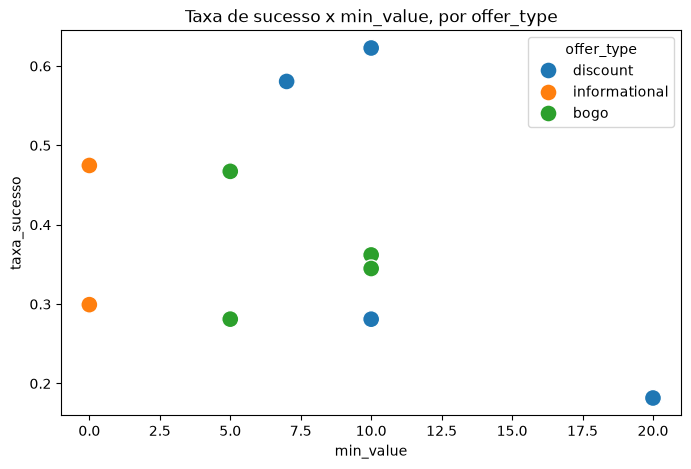

In [18]:
# Dispersao: taxa de sucesso x min_value, por offer_type
# (min_value=0 e sempre "informational", entao aparece isolado a esquerda)
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=ranking_pd, x="min_value", y="taxa_sucesso", hue="offer_type", s=150
)
plt.title("Taxa de sucesso x min_value, por offer_type")
plt.show();

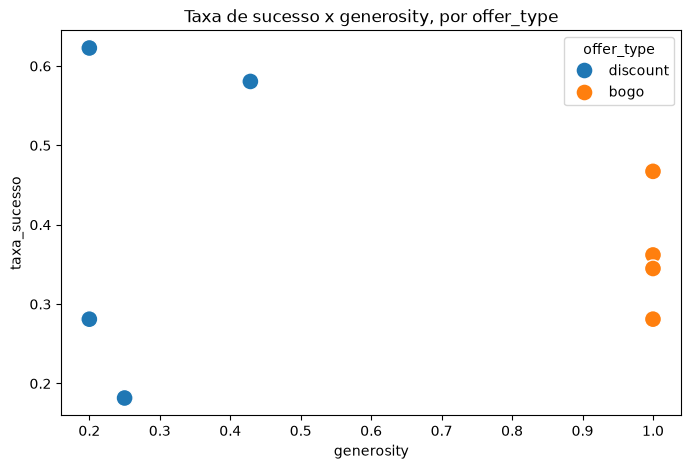

In [19]:
# Dispersao: taxa de sucesso x generosity, por offer_type (so faz sentido para bogo/discount,
# ja que informational nao tem generosity definida - min_value sempre 0)
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=ranking_pd.dropna(subset=["generosity"]),
    x="generosity",
    y="taxa_sucesso",
    hue="offer_type",
    s=150,
)
plt.title("Taxa de sucesso x generosity, por offer_type")
plt.show();

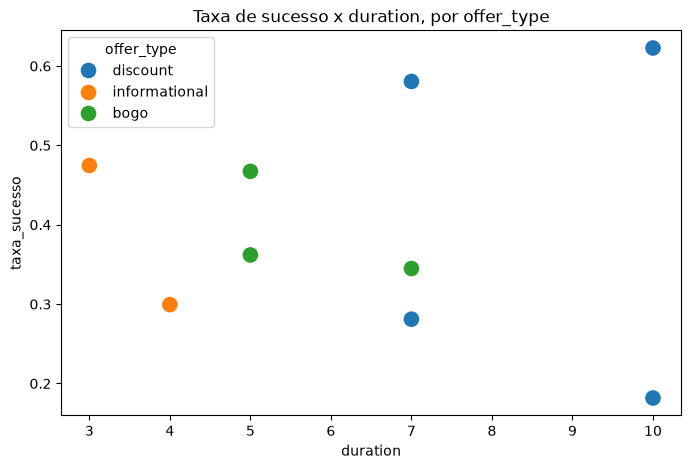

In [20]:
# Dispersao: taxa de sucesso x duration, por offer_type
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=ranking_pd, x="duration", y="taxa_sucesso", hue="offer_type", s=150
)
plt.title("Taxa de sucesso x duration, por offer_type")
plt.show();

In [21]:
# Correlacao entre os atributos economicos e a taxa de sucesso, a nivel de oferta (n=10, cuidado
# ao interpretar - amostra pequena, serve mais como direcao do que como evidencia estatistica forte)
ranking_pd[
    ["min_value", "discount_value", "duration", "generosity", "taxa_sucesso"]
].corr()

,min_value,discount_value,duration,generosity,taxa_sucesso
min_value,1.000000,0.465686,0.808414,-0.521654,-0.328145
discount_value,0.465686,1.000000,0.160262,0.751717,-0.238282
duration,0.808414,0.160262,1.000000,-0.739348,-0.031798
generosity,-0.521654,0.751717,-0.739348,1.000000,-0.119639
taxa_sucesso,-0.328145,-0.238282,-0.031798,-0.119639,1.000000


**Conclusoes do step 3.5:**
1. `min_value` tem a correlacao mais forte (negativa) com a taxa de sucesso (`-0.33`) entre as variaveis economicas - confirma o padrao ja notado no 3.4 (barreira de entrada mais alta reduz conversao).
2. `min_value` e `duration` sao fortemente correlacionados entre si (`0.81`) - isso e esperado, ja que a EDA 01 ja tinha identificado essa relacao dentro de `discount`. Isso significa que os dois efeitos estao confundidos aqui: nao da para isolar "efeito de min_value" de "efeito de duration" olhando apenas essas 10 ofertas agregadas.
3. Um padrao interessante aparece ao fixar `min_value=10` em `discount`: a oferta com `duration=10` (10 dias para usar) tem taxa 0.62, enquanto a com `duration=7` tem taxa 0.28 - ou seja, para o mesmo valor minimo, mais tempo para resgatar parece ajudar bastante. Isso sugere uma possivel **interacao** entre `min_value` e `duration` (tempo relativo a exigencia de compra), nao efeitos puramente aditivos.
4. `generosity` (`discount_value/min_value`) tem correlacao fraca com sucesso (`-0.12`) no agregado, mas isso mistura tipos de oferta diferentes (bogo sempre tem generosity=1.0 por definicao). Dentro de `discount`, a variacao de generosity (0.20 a 0.43) nao explica sozinha o ranking de sucesso.
5. **Limitacao importante**: com apenas 10 ofertas e variaveis colineares, correlacoes agregadas a nivel de oferta tem baixo poder estatistico e nao devem ser usadas como conclusao definitiva - servem apenas para gerar hipoteses. O sinal real (e as possiveis interacoes) devera ser capturado no nivel de instancia (63288 linhas) durante a modelagem, onde um modelo baseado em arvores (LightGBM/XGBoost) consegue capturar interacoes nao-lineares entre `min_value`, `duration` e as demais features sem precisar especifica-las manualmente.

## 3.6 - Segmentacao de cliente vs sucesso
Vamos ver se atributos do cliente (`age`, `gender`, `credit_card_limit`, reaproveitando os buckets da EDA 02) e uma nova dimensao de "tenure" (tempo de cadastro, a partir de `registered_on`) tem relacao com a taxa de sucesso.

**Decisao sobre tenure**: `received_time` e um offset relativo (dias desde o inicio do teste, 0-30), enquanto `registered_on` e uma data de calendario absoluta - nao temos a data absoluta de inicio do teste para reconciliar as duas. Por isso, vamos bucketizar por recencia de calendario de `registered_on` (ex: por ano de cadastro), em vez de tentar calcular "dias de conta na hora do recebimento da oferta".

In [22]:
# Taxa de sucesso por faixa etaria (mesmos buckets da EDA 02), incluindo um bucket "Desconhecido"
# para os nulos de cadastro incompleto
offer_instances_bucketed = offer_instances.withColumn(
    "age_bucket",
    F.when(F.col("age").isNull(), "Desconhecido")
    .when(F.col("age") < 30, "18-29")
    .when(F.col("age") < 45, "30-44")
    .when(F.col("age") < 60, "45-59")
    .otherwise("60+"),
)

offer_instances_bucketed.groupBy("age_bucket").agg(
    F.avg("success").alias("taxa_sucesso"), F.count("*").alias("total")
).orderBy("age_bucket").show()

+------------+-------------------+-----+
|  age_bucket|       taxa_sucesso|total|
+------------+-------------------+-----+
|       18-29| 0.3348561759729272| 5910|
|       30-44|0.41894449116904964| 9512|
|       45-59|0.43775413579903083|17953|
|         60+|0.43195862132100515|21847|
|Desconhecido|0.17046863377138607| 8066|
+------------+-------------------+-----+



In [23]:
# Taxa de sucesso por genero (F/M/O/NULL - NULL pertence ao mesmo grupo de cadastro incompleto)
offer_instances.groupBy("gender").agg(
    F.avg("success").alias("taxa_sucesso"), F.count("*").alias("total")
).orderBy(F.desc("taxa_sucesso")).show()

+------+-------------------+-----+
|gender|       taxa_sucesso|total|
+------+-------------------+-----+
|     O| 0.5279583875162549|  769|
|     F|0.46308312872676255|22808|
|     M| 0.3884341918154527|31645|
|  NULL|0.17046863377138607| 8066|
+------+-------------------+-----+



In [24]:
# Taxa de sucesso por faixa de credit_card_limit (quartis aproximados vistos na EDA 02: 49k/64k/80k)
offer_instances_bucketed = offer_instances_bucketed.withColumn(
    "credit_limit_bucket",
    F.when(F.col("credit_card_limit").isNull(), "Desconhecido")
    .when(F.col("credit_card_limit") <= 49000, "<=49k")
    .when(F.col("credit_card_limit") <= 64000, "49k-64k")
    .when(F.col("credit_card_limit") <= 80000, "64k-80k")
    .otherwise(">80k"),
)

offer_instances_bucketed.groupBy("credit_limit_bucket").agg(
    F.avg("success").alias("taxa_sucesso"), F.count("*").alias("total")
).orderBy("credit_limit_bucket").show()

+-------------------+-------------------+-----+
|credit_limit_bucket|       taxa_sucesso|total|
+-------------------+-------------------+-----+
|            49k-64k|  0.436067384700359|14484|
|            64k-80k| 0.4559802528236966|13369|
|              <=49k| 0.3252344416027281|14076|
|               >80k|0.47167682238772285|13293|
|       Desconhecido|0.17046863377138607| 8066|
+-------------------+-------------------+-----+



In [25]:
# Taxa de sucesso por ano de cadastro ("tenure" por recencia de calendario - ver decisao acima)
# registered_on varia de 2013-07-29 a 2018-07-26 (visto na EDA 02)
offer_instances_bucketed = offer_instances_bucketed.withColumn(
    "registration_year", F.year("registered_on")
)

offer_instances_bucketed.groupBy("registration_year").agg(
    F.avg("success").alias("taxa_sucesso"), F.count("*").alias("total")
).orderBy("registration_year").show()

+-----------------+-------------------+-----+
|registration_year|       taxa_sucesso|total|
+-----------------+-------------------+-----+
|             2013|0.42670401493930904| 1071|
|             2014|0.43682170542635657| 2580|
|             2015| 0.4836041358936484| 6770|
|             2016| 0.5153716732945856|13076|
|             2017|0.38125882255252014|24086|
|             2018| 0.2454632282712512|15705|
+-----------------+-------------------+-----+



/mnt/HD2/Data_Science/ifood-case/.venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


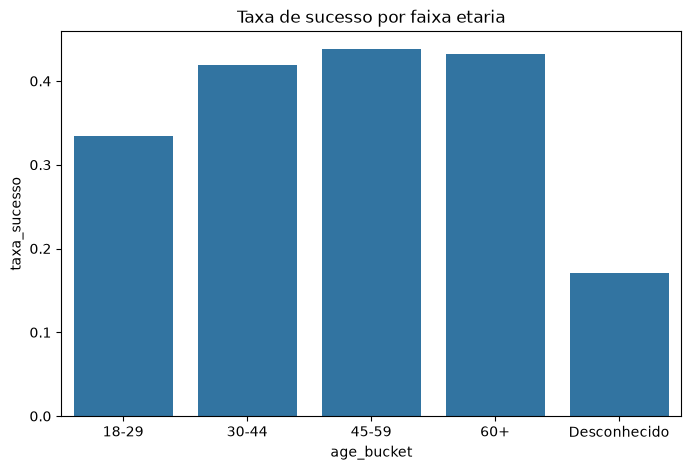

In [26]:
# Grafico de barras: taxa de sucesso por faixa etaria
age_success_pd = (
    offer_instances_bucketed.groupBy("age_bucket")
    .agg(F.avg("success").alias("taxa_sucesso"))
    .toPandas()
)
plt.figure(figsize=(8, 5))
sns.barplot(
    data=age_success_pd,
    x="age_bucket",
    y="taxa_sucesso",
    order=["18-29", "30-44", "45-59", "60+", "Desconhecido"],
)
plt.title("Taxa de sucesso por faixa etaria")
plt.show();

/mnt/HD2/Data_Science/ifood-case/.venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


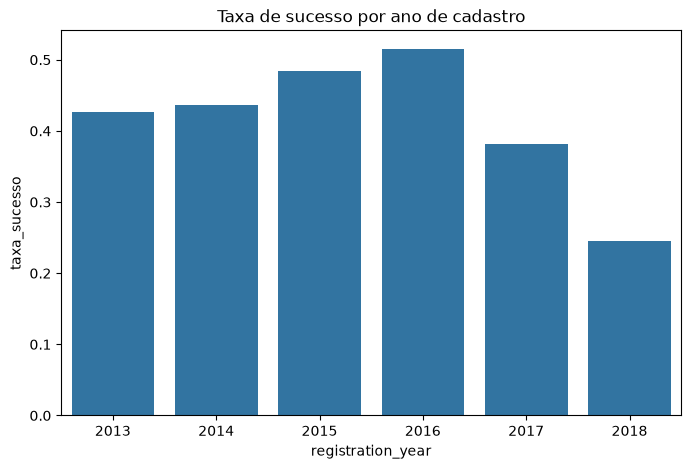

In [27]:
# Grafico de barras: taxa de sucesso por ano de cadastro
year_success_pd = (
    offer_instances_bucketed.groupBy("registration_year")
    .agg(F.avg("success").alias("taxa_sucesso"))
    .toPandas()
    .sort_values("registration_year")
)
plt.figure(figsize=(8, 5))
sns.barplot(data=year_success_pd, x="registration_year", y="taxa_sucesso")
plt.title("Taxa de sucesso por ano de cadastro")
plt.show();

/mnt/HD2/Data_Science/ifood-case/.venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


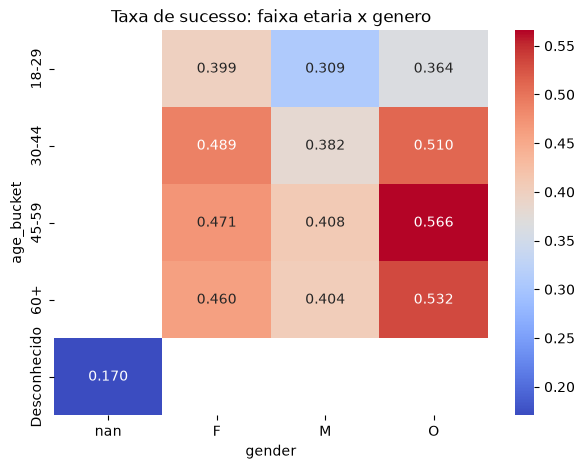

In [28]:
# Cruzamento age_bucket x gender - para ver se existe interacao entre as duas dimensoes
crosstab_pd = (
    offer_instances_bucketed.groupBy("age_bucket", "gender")
    .agg(F.avg("success").alias("taxa_sucesso"), F.count("*").alias("total"))
    .toPandas()
)
crosstab_pivot = crosstab_pd.pivot(
    index="age_bucket", columns="gender", values="taxa_sucesso"
).reindex(["18-29", "30-44", "45-59", "60+", "Desconhecido"])

plt.figure(figsize=(7, 5))
sns.heatmap(crosstab_pivot, annot=True, fmt=".3f", cmap="coolwarm")
plt.title("Taxa de sucesso: faixa etaria x genero")
plt.show();

**Conclusoes do step 3.6:**
1. **Idade**: tendencia crescente ate a faixa `45-59` (0.4378), com leve queda em `60+` (0.4320); `18-29` e a faixa com menor taxa entre os conhecidos (0.3349).
2. **Genero**: `O` tem a maior taxa (0.5280), seguido de `F` (0.4631) e `M` (0.3884). Esse padrao se repete de forma consistente dentro de cada faixa etaria no heatmap (sem inversao de ordem), sugerindo um efeito de genero relativamente independente da idade.
3. **credit_card_limit**: relacao praticamente monotonica - quanto maior o limite, maior a taxa de sucesso (`<=49k`: 0.3252 -> `49k-64k`: 0.4361 -> `64k-80k`: 0.4560 -> `>80k`: 0.4717). Faz sentido: clientes com maior limite tendem a ter maior poder de compra/engajamento.
4. **Tenure (ano de cadastro)** - achado mais interessante e nao-monotonico: a taxa sobe de 2013 (0.4267) ate um pico em 2016 (0.5154), mas cai fortemente em 2017 (0.3813) e principalmente em 2018 (0.2455). Ou seja, clientes cadastrados mais recentemente (na epoca do teste) convertem bem menos que os mais antigos - pode indicar que clientes novos ainda nao estao "aquecidos"/engajados o suficiente com o app, ou que o teste incluiu uma leva grande de cadastros novos com perfil de consumo diferente.
5. **Grupo "Desconhecido"** (cadastro incompleto, `age=118` original) tem a menor taxa de sucesso isolada em toda a analise (0.1705) - bem abaixo de qualquer outro segmento em qualquer dimensao. Isso e um sinal forte: vale a pena criar uma feature explicita tipo `is_profile_complete` na engenharia de features (Fase 4), ja que esse grupo se comporta de forma bem diferente do restante da base.
6. Combinando os achados: `age`, `gender`, `credit_card_limit` e o novo `registration_year`/tenure sao todos candidatos solidos a features de segmentacao para a modelagem, com destaque para tenure (efeito nao-linear/nao-monotonico, dificil de capturar com um modelo linear simples) e para o flag de cadastro incompleto.

## 3.7 - Checkpoint do grupo de controle (Option A completa)
Ja sabiamos, desde a EDA 03, que apenas 6 de 17000 clientes nunca receberam nenhuma oferta - ou seja, nao existe um grupo de controle "puro" (entre clientes). Aqui vamos investigar uma alternativa: um controle **dentro do mesmo cliente** (within-subject), usando os periodos em que o cliente nao tinha nenhuma oferta ativa ("janelas organicas") como proxy de comportamento de base, para comparar com o comportamento durante as janelas de oferta.

Sub-etapas:
1. **3.7a** - Para cada cliente, ordenar as instancias de oferta por `received_time` e calcular os "gaps" (intervalos sem oferta ativa): antes da primeira oferta, entre ofertas consecutivas, e depois da ultima oferta ate o fim da janela do teste.
2. **3.7b** - Olhar a distribuicao do tamanho desses gaps e decidir um tamanho minimo razoavel para considerar um gap como "janela organica" utilizavel (gaps muito curtos nao dão tempo de observar uma transacao organica).
3. **3.7c** - Para cada janela organica, verificar se existe pelo menos uma transacao (evento `transaction` bruto) dentro do intervalo - um proxy de "o cliente compraria de qualquer forma".
4. **3.7d** - Comparar a taxa de transacao organica (baseline) com a taxa de sucesso das janelas tratadas (com oferta), no agregado e por `offer_type`, e concluir se um uplift T-Learner (comparando janela tratada vs janela organica do mesmo cliente) e viavel para a Fase 5, ou se o modelo de resposta/propensao continua sendo a abordagem mais segura.

In [29]:
# Leitura das transacoes brutas, so precisamos do evento "transaction" (compra organica, sem oferta)
transactions_raw = spark.read.option("multiline", "true").json(
    "../data/raw/transactions.json"
)
transaction_events = transactions_raw.filter(F.col("event") == "transaction").select(
    "account_id", F.col("time_since_test_start").alias("transaction_time")
)

# Fim real do periodo de teste (visto na EDA 03 como ~29.75, calculando aqui de forma dinamica)
test_end = transactions_raw.select(F.max("time_since_test_start")).first()[0]
print(f"Fim do periodo de teste (test_end): {test_end}")

Fim do periodo de teste (test_end): 29.75


In [31]:
# 3.7a - Para cada cliente, calcular o "gap" (janela sem oferta ativa) ANTES de cada oferta recebida:
# do fim da janela da oferta anterior (ou do inicio do teste, dia 0, se for a primeira oferta do
# cliente) ate o inicio da oferta atual.
customer_window = Window.partitionBy("account_id").orderBy("received_time")

gaps_before = (
    offer_instances.select("account_id", "received_time", "window_end")
    .withColumn("prev_window_end", F.lag("window_end").over(customer_window))
    .withColumn("gap_start", F.coalesce(F.col("prev_window_end"), F.lit(0.0)))
    .withColumn("gap_end", F.col("received_time"))
    .select("account_id", "gap_start", "gap_end")
)

gaps_before.show(10)

+--------------------+---------+-------+
|          account_id|gap_start|gap_end|
+--------------------+---------+-------+
|0009655768c64bdeb...|      0.0|    7.0|
|0009655768c64bdeb...|     10.0|   14.0|
|0009655768c64bdeb...|     18.0|   17.0|
|0009655768c64bdeb...|     22.0|   21.0|
|0009655768c64bdeb...|     31.0|   24.0|
|00116118485d4dfda...|      0.0|    7.0|
|0011e0d4e6b944f99...|      0.0|    0.0|
|0011e0d4e6b944f99...|      4.0|    7.0|
|0011e0d4e6b944f99...|     14.0|   14.0|
|0011e0d4e6b944f99...|     17.0|   17.0|
+--------------------+---------+-------+
only showing top 10 rows


**Observacao importante ja no 3.7a**: alguns `gap_end` ficaram **menores** que `gap_start` (ex: `gap_start=18.0` e `gap_end=17.0`). Isso significa que o cliente recebeu uma nova oferta **antes** da janela da oferta anterior terminar - ou seja, as janelas de oferta se sobrepoem para esse cliente, e nao existe gap organico real nesse ponto. Vamos calcular tambem o gap apos a ultima oferta de cada cliente (ate o fim do teste) e depois filtrar so os gaps com duracao positiva.

In [32]:
# Gap depois da ultima oferta de cada cliente, ate o fim do periodo de teste
last_window_end = offer_instances.groupBy("account_id").agg(
    F.max("window_end").alias("last_window_end")
)

gaps_after = last_window_end.select(
    "account_id",
    F.col("last_window_end").alias("gap_start"),
    F.lit(test_end).alias("gap_end"),
)

# Uniao de todos os gaps candidatos (antes + depois) e calculo da duracao de cada um
all_gaps = gaps_before.unionByName(gaps_after).withColumn(
    "gap_length", F.col("gap_end") - F.col("gap_start")
)

print(f"Total de gaps candidatos: {all_gaps.count()}")
all_gaps.select("gap_length").summary().show()

Total de gaps candidatos: 80282
+-------+------------------+
|summary|        gap_length|
+-------+------------------+
|  count|             80282|
|   mean|1.1424540992999677|
| stddev| 4.428137992689785|
|    min|              -7.0|
|    25%|             -1.25|
|    50%|               0.0|
|    75%|               3.0|
|    max|             26.75|
+-------+------------------+



**Achado forte ja aqui**: a mediana de `gap_length` e `0.0` e o percentil 25 e negativo (`-1.25`). Ou seja, para a maioria dos clientes as janelas de oferta se sobrepoem praticamente o tempo todo - gaps organicos "de verdade" (positivos e razoavelmente longos) parecem ser a minoria. So a partir do percentil 75 (`3.0` dias) os gaps comecam a ficar utilizaveis. Vamos visualizar a distribuicao antes de decidir um corte minimo (3.7b).

/mnt/HD2/Data_Science/ifood-case/.venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


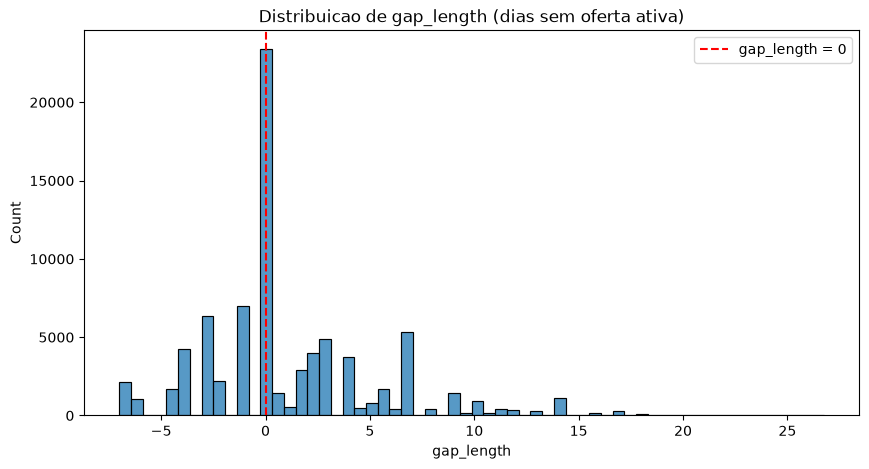

In [33]:
# 3.7b - Distribuicao de gap_length (histograma), para decidir um corte minimo razoavel
gap_length_pd = all_gaps.select("gap_length").toPandas()

plt.figure(figsize=(10, 5))
sns.histplot(gap_length_pd["gap_length"], bins=60)
plt.axvline(0, color="red", linestyle="--", label="gap_length = 0")
plt.title("Distribuicao de gap_length (dias sem oferta ativa)")
plt.legend()
plt.show();

In [ ]:
# Quantos gaps sobram em diferentes cortes minimos - a menor duration entre as 10 ofertas e 3 dias
# (visto no 3.4/3.5), entao faz sentido usar isso como referencia de "tempo minimo para uma compra
# organica ser comparavel a uma janela de oferta".
for threshold in [0, 1, 3, 5, 7]:
    n = all_gaps.filter(F.col("gap_length") >= threshold).count()
    print(
        f"gap_length >= {threshold}: {n} janelas ({n / all_gaps.count():.1%} do total)"
    )

gap_length >= 0: 55573 janelas (69.2% do total)
gap_length >= 1: 30724 janelas (38.3% do total)
gap_length >= 3: 22045 janelas (27.5% do total)
gap_length >= 5: 14214 janelas (17.7% do total)
gap_length >= 7: 11363 janelas (14.2% do total)


**Decisao de corte**: vamos usar `gap_length >= 3` (a menor `duration` entre as 10 ofertas do dataset, vista no 3.4/3.5) como definicao de "janela organica utilizavel" - fica com `22045` janelas (27.5% dos gaps candidatos), uma amostra ainda bem robusta para estimar uma taxa de base.

In [35]:
# Janelas organicas utilizaveis + id unico por janela (necessario pois um mesmo account_id pode ter
# mais de uma janela organica)
organic_windows = all_gaps.filter(F.col("gap_length") >= 3).withColumn(
    "gap_id", F.monotonically_increasing_id()
)

print(f"Janelas organicas utilizaveis: {organic_windows.count()}")
organic_windows.show(5)

Janelas organicas utilizaveis: 22045
+--------------------+---------+-------+----------+------+
|          account_id|gap_start|gap_end|gap_length|gap_id|
+--------------------+---------+-------+----------+------+
|0009655768c64bdeb...|      0.0|    7.0|       7.0|     0|
|0009655768c64bdeb...|     10.0|   14.0|       4.0|     1|
|00116118485d4dfda...|      0.0|    7.0|       7.0|     2|
|0011e0d4e6b944f99...|      4.0|    7.0|       3.0|     3|
|0020c2b971eb4e918...|     14.0|   17.0|       3.0|     4|
+--------------------+---------+-------+----------+------+
only showing top 5 rows


In [37]:
# 3.7c - Para cada janela organica, verificar se existe pelo menos uma transacao (evento bruto
# "transaction") do mesmo account_id dentro do intervalo [gap_start, gap_end).
# left_semi mantem so as janelas organicas que tem pelo menos um match (mesmo padrao usado no
# processamento, notebook 04, para "has_post_view_transaction").
ow = organic_windows.alias("ow")
te = transaction_events.alias("te")

organic_with_transaction = ow.join(
    te,
    on=(
        (F.col("ow.account_id") == F.col("te.account_id"))
        & (F.col("te.transaction_time") >= F.col("ow.gap_start"))
        & (F.col("te.transaction_time") < F.col("ow.gap_end"))
    ),
    how="left_semi",
).select("gap_id")

organic_windows_labeled = organic_windows.join(
    organic_with_transaction.withColumn("has_organic_transaction", F.lit(True)),
    on="gap_id",
    how="left",
).fillna(False, subset=["has_organic_transaction"])

organic_windows_labeled.select(
    F.avg(F.col("has_organic_transaction").cast("int")).alias("taxa_transacao_organica")
).show()

+-----------------------+
|taxa_transacao_organica|
+-----------------------+
|      0.460966205488773|
+-----------------------+



**Atencao a comparacao justa**: a taxa organica (`46.1%`) mede "pelo menos uma transacao na janela", enquanto `success` (`38.9%` geral) e uma definicao mais estrita (fluxo de visualizacao + conclusao da oferta, nao so uma compra qualquer). Para comparar de forma justa, precisamos olhar tambem a taxa de "pelo menos uma transacao dentro da janela de oferta" no grupo tratado (`has_post_view_transaction`), que e a metrica equivalente a organica.

In [ ]:
# 3.7d - Comparacao justa: taxa de "pelo menos uma transacao" tratada (has_post_view_transaction)
# vs organica, geral e por offer_type
treated_transaction_rate = offer_instances.select(
    F.avg(F.col("has_post_view_transaction").cast("int")).alias(
        "taxa_transacao_tratada"
    )
).first()[0]

organic_transaction_rate = organic_windows_labeled.select(
    F.avg(F.col("has_organic_transaction").cast("int"))
).first()[0]

print(
    f"Taxa de transacao TRATADA  (has_post_view_transaction, geral): {treated_transaction_rate:.4f}"
)
print(
    f"Taxa de transacao ORGANICA (janelas sem oferta, gap>=3 dias):  {organic_transaction_rate:.4f}"
)
print(
    f"Diferenca (tratada - organica): {treated_transaction_rate - organic_transaction_rate:+.4f}"
)

print("\nPor offer_type (tratada):")
offer_instances.groupBy("offer_type").agg(
    F.avg(F.col("has_post_view_transaction").cast("int")).alias(
        "taxa_transacao_tratada"
    ),
    F.count("*").alias("total"),
).orderBy("offer_type").show()

Taxa de transacao TRATADA  (has_post_view_transaction, geral): 0.5737
Taxa de transacao ORGANICA (janelas sem oferta, gap>=3 dias):  0.4610
Diferenca (tratada - organica): +0.1128

Por offer_type (tratada):
+-------------+----------------------+-----+
|   offer_type|taxa_transacao_tratada|total|
+-------------+----------------------+-----+
|         bogo|    0.6450772086410489|25321|
|     discount|    0.5957497234950229|25316|
|informational|   0.38692593470871867|12651|
+-------------+----------------------+-----+



### Conclusoes 3.7 - Veredito do checkpoint de controle (Option A)

1. **Nao existe grupo de controle "puro"** (so 6 de 17000 clientes nunca receberam oferta - ja sabiamos disso da EDA 01/03), entao a abordagem *within-subject* (comparar o proprio cliente em janelas com e sem oferta ativa) e a unica viavel para estimar uma linha de base organica.
2. **Sobreposicao de janelas e a norma, nao a excecao**: ao calcular os gaps entre ofertas recebidas pelo mesmo cliente, a mediana de `gap_length` foi `0.0` dia e o percentil 25 foi negativo (`-1.25`), confirmando que a maioria dos clientes tem janelas de oferta se sobrepondo continuamente. So `27.5%` dos gaps candidatos (`22045` de `80282`) tiveram duracao util (`>= 3` dias, a menor `duration` entre as 10 ofertas).
3. **Taxa de transacao organica (baseline) = `46.10%`** (pelo menos uma compra dentro de uma janela organica de `>=3` dias, sem oferta ativa).
4. **Comparacao justa** (mesma metrica "pelo menos uma transacao na janela"): tratada geral = `57.37%` vs organica = `46.10%`, uma diferenca de `+11.28 p.p.`. Por `offer_type`:
   - `bogo`: `64.51%` (uplift ~`+18.4 p.p.` sobre a organica)
   - `discount`: `59.57%` (uplift ~`+13.5 p.p.` sobre a organica)
   - `informational`: `38.69%` (uplift **negativo**, `~-7.4 p.p.` abaixo da organica - efeito nulo ou levemente negativo)
5. **Veredito**: existe sinal real de incrementalidade para `bogo` e `discount`, o que **justifica explorar uplift modeling (T-Learner tratado vs. janela organica) como analise complementar na Fase 5**, mas o resultado para `informational` reforca a suspeita (ja levantada no 3.3) de que esse tipo de oferta pode nao estar gerando compras incrementais reais - o cliente provavelmente compraria de qualquer forma. Dado o baixo numero de ofertas distintas (10) e a natureza exploratoria dessa estimativa de baseline (amostra de gaps nao e uma randomizacao real), o **modelo de propensao/resposta (Fase 5, entrega principal) continua sendo a entrega central**; uplift modeling entra como analise secundaria/sensibilidade, nao como substituto.

## 3.8 - Fadiga de ofertas (offer load)
Sera que o cliente fica menos receptivo a medida que recebe mais ofertas ao longo do teste? Vamos numerar as ofertas recebidas por cada cliente em ordem cronologica (1a, 2a, 3a...) e comparar a taxa de sucesso por posicao na sequencia.

In [5]:
# Quantas ofertas cada cliente recebeu no total (distribuicao)
offers_per_customer = offer_instances.groupBy("account_id").agg(
    F.count("*").alias("qtd_ofertas")
)
offers_per_customer.groupBy("qtd_ofertas").count().orderBy("qtd_ofertas").show()

+-----------+-----+
|qtd_ofertas|count|
+-----------+-----+
|          1|  172|
|          2| 1599|
|          3| 5038|
|          4| 6563|
|          5| 3180|
|          6|  442|
+-----------+-----+



In [6]:
# Numerando as ofertas de cada cliente em ordem cronologica (1a, 2a, 3a...) e calculando a taxa de
# sucesso por posicao na sequencia
customer_window = Window.partitionBy("account_id").orderBy("received_time")

offer_instances_seq = offer_instances.withColumn(
    "offer_sequence", F.row_number().over(customer_window)
)

fatigue_pd = (
    offer_instances_seq.groupBy("offer_sequence")
    .agg(F.avg("success").alias("taxa_sucesso"), F.count("*").alias("total"))
    .orderBy("offer_sequence")
    .toPandas()
)
fatigue_pd

/mnt/HD2/Data_Science/ifood-case/.venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


,offer_sequence,taxa_sucesso,total
0,1,0.386372,16994
1,2,0.400428,16822
2,3,0.389017,15223
3,4,0.380461,10185
4,5,0.381833,3622
5,6,0.346154,442


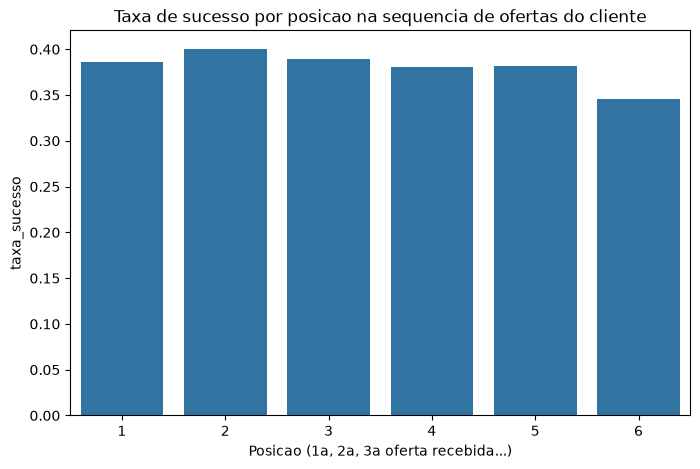

In [7]:
# Grafico de barras: taxa de sucesso por posicao na sequencia de ofertas
plt.figure(figsize=(8, 5))
sns.barplot(data=fatigue_pd, x="offer_sequence", y="taxa_sucesso")
plt.title("Taxa de sucesso por posicao na sequencia de ofertas do cliente")
plt.xlabel("Posicao (1a, 2a, 3a oferta recebida...)")
plt.show();

**Conclusoes do step 3.8:**
1. Cada cliente recebe entre `1` e `6` ofertas ao longo do teste, com a maioria concentrada entre `3` e `5` (moda em `4` ofertas, `6563` clientes).
2. **Nao ha sinal claro de fadiga**: a taxa de sucesso se mantem estavel entre a 1a e a 5a oferta (`0.386` -> `0.400` -> `0.389` -> `0.380` -> `0.382`), sem tendencia de queda consistente. So a 6a oferta cai um pouco mais (`0.346`), mas com amostra pequena (`442` clientes) - pode ser ruido, nao um efeito real de saturacao.
3. Isso sugere que **a posicao na sequencia de ofertas (quantas ofertas o cliente ja recebeu) nao parece ser, isoladamente, um preditor forte de sucesso** - diferente do que se esperaria se houvesse fadiga de marketing relevante nesse periodo de ~30 dias. Ainda assim, vale manter `offer_sequence` (ou `qtd_ofertas` acumulada ate o momento) como feature candidata na Fase 4, ja que um modelo nao-linear pode capturar interacoes com outras variaveis (ex: fadiga pode existir so para determinados segmentos/tipos de oferta) que uma media agregada simples nao revela.

## 3.9 - Padroes temporais (`received_time`)
Vamos ver como as ofertas foram distribuidas ao longo da janela de ~30 dias do teste, e se o dia em que a oferta foi recebida tem alguma relacao com a taxa de sucesso (ex: efeito de calendario/sazonalidade dentro do teste).

In [8]:
# Valores distintos de received_time (dias em que ofertas foram enviadas) e taxa de sucesso em cada um
received_time_pd = (
    offer_instances.groupBy("received_time")
    .agg(F.avg("success").alias("taxa_sucesso"), F.count("*").alias("total"))
    .orderBy("received_time")
    .toPandas()
)
received_time_pd

/mnt/HD2/Data_Science/ifood-case/.venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


,received_time,taxa_sucesso,total
0,0.0,0.378261,12650
1,7.0,0.400171,11710
2,14.0,0.397482,10881
3,17.0,0.399743,10134
4,21.0,0.388758,9358
5,24.0,0.368206,8555


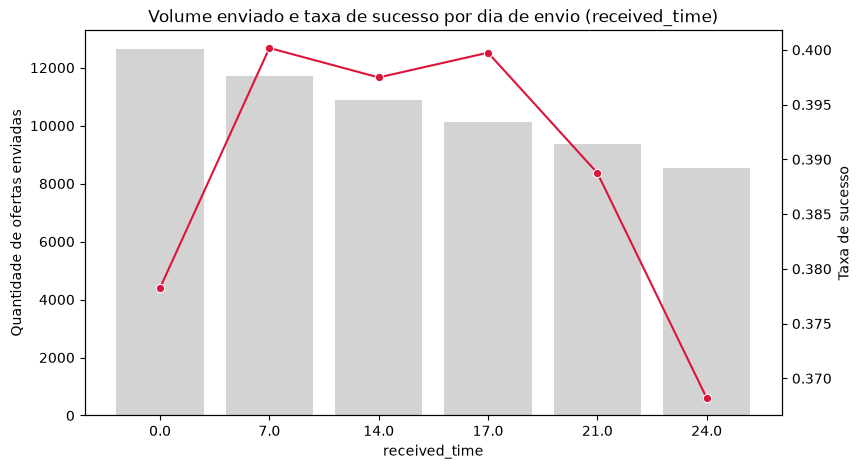

In [9]:
# So existem 6 dias distintos de envio (ofertas enviadas em lotes, nao continuamente).
# Grafico combinado: volume de ofertas enviadas (barras) e taxa de sucesso (linha) por dia de envio.
fig, ax1 = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=received_time_pd, x="received_time", y="total", color="lightgray", ax=ax1
)
ax1.set_ylabel("Quantidade de ofertas enviadas")

ax2 = ax1.twinx()
sns.lineplot(
    data=received_time_pd,
    x=range(len(received_time_pd)),
    y="taxa_sucesso",
    marker="o",
    color="crimson",
    ax=ax2,
)
ax2.set_ylabel("Taxa de sucesso")
plt.title("Volume enviado e taxa de sucesso por dia de envio (received_time)")
plt.show();

In [10]:
# A queda de volume e da taxa de sucesso no ultimo dia (24.0) pode ser confundida com o mix de
# offer_type enviado naquele lote. Vamos checar a composicao de offer_type por dia de envio.
mix_pd = (
    offer_instances.groupBy("received_time", "offer_type")
    .agg(F.count("*").alias("total"))
    .toPandas()
)
mix_pivot = mix_pd.pivot(
    index="received_time", columns="offer_type", values="total"
).fillna(0)
mix_pivot_pct = mix_pivot.div(mix_pivot.sum(axis=1), axis=0)
mix_pivot_pct

/mnt/HD2/Data_Science/ifood-case/.venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


offer_type,bogo,discount,informational
received_time,,,
0.0,0.396680,0.402609,0.200711
7.0,0.403330,0.396755,0.199915
14.0,0.399779,0.399871,0.200349
17.0,0.403395,0.398165,0.198441
21.0,0.398803,0.404146,0.197051
24.0,0.398597,0.398480,0.202922


In [ ]:
# O mix de offer_type e praticamente identico entre os dias de envio (~40% bogo/40% discount/20%
# informational em todos), entao a queda de sucesso no ultimo lote (24.0) NAO e explicada por mix.
# Hipotese alternativa: "censura a direita" - ofertas enviadas mais tarde tem a janela de validade
# (window_end = received_time + duration) mais proxima ou alem do fim do teste (test_end=29.75),
# sobrando menos tempo real para o cliente completar a oferta antes dos dados acabarem.
offer_instances.withColumn(
    "window_end", F.col("received_time") + F.col("duration")
).withColumn("janela_truncada", F.col("window_end") > F.lit(29.75)).groupBy(
    "received_time"
).agg(
    F.avg(F.col("janela_truncada").cast("int")).alias("pct_janela_truncada"),
    F.count("*").alias("total"),
).orderBy("received_time").show()

+-------------+-------------------+-----+
|received_time|pct_janela_truncada|total|
+-------------+-------------------+-----+
|          0.0|                0.0|12650|
|          7.0|                0.0|11710|
|         14.0|                0.0|10881|
|         17.0|                0.0|10134|
|         21.0|0.20303483650352638| 9358|
|         24.0| 0.6049094097019287| 8555|
+-------------+-------------------+-----+



**Conclusoes do step 3.9:**
1. As ofertas foram enviadas em apenas **6 lotes discretos** ao longo do teste (dias `0, 7, 14, 17, 21, 24`), nao de forma continua - reforca que `received_time` e melhor tratado como uma variavel categorica/ordinal de "lote de envio" do que uma variavel continua qualquer.
2. O volume enviado cai a cada lote (`12650` -> `8555`), o que faz sentido: a base de clientes elegiveis para receber uma nova oferta provavelmente diminui (alguns ja estao com oferta ativa / dentro do intervalo minimo entre envios).
3. A taxa de sucesso parece cair no ultimo lote (`24.0`: `0.368` vs `~0.39-0.40` nos demais), mas isso **NAO e explicado por diferenca no mix de offer_type** (a proporcao bogo/discount/informational e praticamente identica em todos os lotes, ~40%/40%/20%).
4. **Achado real: censura por fim do periodo de teste**. `60.5%` das ofertas enviadas no ultimo lote (`24.0`) tem a janela de validade (`window_end = received_time + duration`) ultrapassando o fim real do teste (`29.75`), e `20.3%` no penultimo lote (`21.0`) - ou seja, para essas instancias o cliente pode nao ter tido tempo suficiente de fato para completar a oferta antes dos dados acabarem, o que reduz artificialmente a taxa de sucesso observada (nao e um efeito real de "o cliente ficou menos receptivo", e sim um efeito de censura/truncamento nos dados).
5. **Implicacao para a modelagem**: vale considerar uma feature explicita indicando o quanto da janela da oferta ficou "dentro" do periodo observado (ex: `dias_restantes_no_teste` ou um flag `janela_truncada`), e ter cautela ao interpretar a queda de sucesso nos ultimos lotes como um efeito de negocio real.

## 3.10 - Resumo de correlacao (nivel de instancia)
No 3.5 olhamos a correlacao a nivel de oferta (n=10, baixo poder estatistico). Agora vamos calcular a correlacao das variaveis numericas com `success` diretamente a nivel de instancia (`63288` linhas), o que da um sinal estatisticamente mais confiavel sobre quais features priorizar na Fase 4.

In [12]:
# Selecionando as variaveis numericas relevantes (economicas da oferta + perfil do cliente) e
# calculando "generosity" a nivel de instancia (igual ao 3.5, agora aplicado linha a linha)
numeric_cols = offer_instances.withColumn(
    "generosity",
    F.when(F.col("min_value") == 0, None).otherwise(
        F.col("discount_value") / F.col("min_value")
    ),
).select(
    "discount_value",
    "min_value",
    "duration",
    "generosity",
    "age",
    "credit_card_limit",
    "success",
)

corr_pd = numeric_cols.toPandas().corr()
corr_pd

/mnt/HD2/Data_Science/ifood-case/.venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


,discount_value,min_value,duration,generosity,age,credit_card_limit,success
discount_value,1.000000,0.465504,0.160572,0.751764,-0.004516,-0.000485,-0.066153
min_value,0.465504,1.000000,0.808559,-0.521845,-0.003289,-0.000810,-0.091057
duration,0.160572,0.808559,1.000000,-0.739565,-0.001839,-0.001160,-0.009077
generosity,0.751764,-0.521845,-0.739565,1.000000,-0.000574,-0.000896,-0.035631
age,-0.004516,-0.003289,-0.001839,-0.000574,1.000000,0.305247,0.047133
credit_card_limit,-0.000485,-0.000810,-0.001160,-0.000896,0.305247,1.000000,0.090929
success,-0.066153,-0.091057,-0.009077,-0.035631,0.047133,0.090929,1.000000


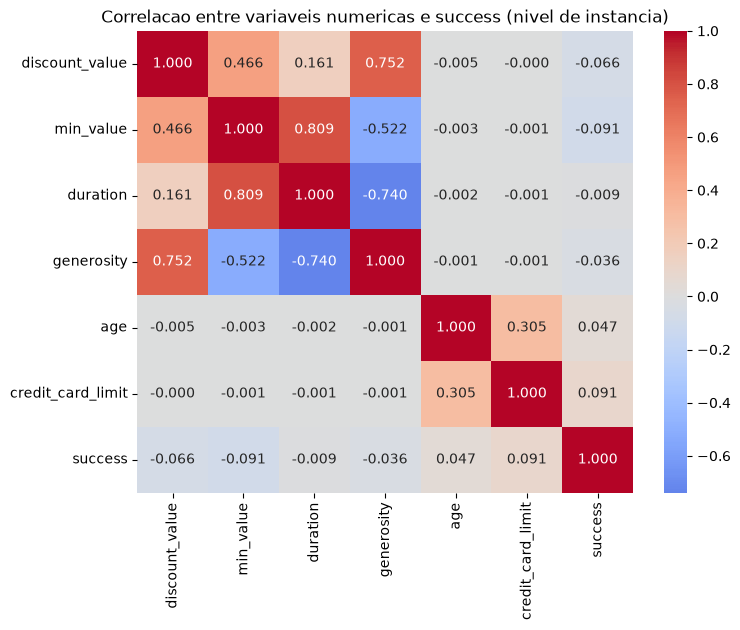

In [13]:
# Heatmap da matriz de correlacao
plt.figure(figsize=(8, 6))
sns.heatmap(corr_pd, annot=True, fmt=".3f", cmap="coolwarm", center=0)
plt.title("Correlacao entre variaveis numericas e success (nivel de instancia)")
plt.show();

**Conclusoes do step 3.10:**
1. **Todas as correlacoes lineares individuais com `success` sao fracas** a nivel de instancia (`|r| <= 0.091` para todas as variaveis testadas) - bem mais fracas do que sugeria a analise agregada por oferta no 3.5 (onde `min_value` chegava a `-0.33`). Isso confirma a suspeita levantada no 3.5: a correlacao agregada por `offer_id` (n=10) estava inflada por baixo poder estatistico/agregacao, e o sinal real e mais sutil e provavelmente nao-linear/dependente de interacoes.
2. Ainda assim, a ordem de importancia relativa se mantem parecida: `min_value` (`-0.091`) e `discount_value` (`-0.066`) sao as economicas mais relevantes (ambas negativas, barreira de entrada prejudica conversao), e `credit_card_limit` (`0.091`) e `age` (`0.047`) sao as de perfil mais relevantes (ambas positivas), consistente com o 3.6.
3. `duration` tem correlacao praticamente nula com `success` isoladamente (`-0.009`), apesar de ter aparecido como parte de uma interacao relevante com `min_value` no 3.5 - reforca que o efeito de `duration` so aparece em conjunto com outras variaveis, nao de forma isolada/linear.
4. **Multicolinearidade confirmada tambem a nivel de instancia**: `min_value` e `duration` continuam fortemente correlacionados (`0.809`), e `generosity` e fortemente correlacionada com as tres variaveis economicas (`discount_value`: `0.752`, `min_value`: `-0.522`, `duration`: `-0.740`) - ela e essencialmente uma combinacao linear das outras, entao nao adiciona muita informacao nova alem delas.
5. **Achado adicional**: `age` e `credit_card_limit` tem uma correlacao moderada entre si (`0.305`), nao reportada explicitamente antes - faz sentido (clientes mais velhos tendem a ter maior limite de credito), mas e outro lembrete de que essas variaveis nao sao totalmente independentes.
6. **Conclusao geral da Fase 3**: como a maioria dos sinais e fraca/nao-linear a nivel individual, a estrategia de modelagem (Fase 5) deve continuar sendo baseada em arvores (LightGBM/XGBoost), que capturam interacoes automaticamente, em vez de um modelo linear simples. `generosity` pode ser descartada ou usada com cautela (redundante com `discount_value`/`min_value`).

## 3.11 - Wrap-up: principais achados da Fase 3 e ponte para a Fase 4

Resumo consolidado de tudo que foi validado nesta EDA detalhada, organizado por tema, para orientar diretamente a engenharia de features (`06_feature_engineering.ipynb`) e a modelagem (Fase 5).

**1. Baseline e integridade dos dados**
- Taxa de sucesso geral = `38.9%`, consistente com o processamento (04). Nulos auditados e todos explicados (cadastro incompleto = `8066` linhas; `viewed_time`/`completed_time`/`reward` nulos coerentes com o funil e com `informational` nunca tendo `completed_time`).

**2. Melhores segmentos e ofertas (negocio)**
- `offer_type`: `discount` (`41.6%`) > `informational` (`38.7%`) > `bogo` (`36.3%`).
- Canal `social` associado as maiores taxas mesmo dentro do mesmo `offer_type`, mas fica sujeito a confundimento com quais ofertas especificas o usam.
- Apenas `10 offer_id` distintos; a melhor oferta (`discount`, `min_value=10`, `duration=10`) atinge `62.3%`, a pior (`discount`, `min_value=20`) cai para `18.2%` - `min_value` baixo e `duration` longa favorecem conversao.
- Segmentacao de cliente: `credit_card_limit` quase monotonico (`32.5%` -> `47.2%`), idade cresce ate `45-59` (`43.8%`), genero `O > F > M` de forma consistente, e clientes cadastrados mais recentemente (`registration_year` 2017/2018) convertem bem menos (`38.1%` / `24.6%` vs pico de `51.5%` em 2016).
- Grupo de cadastro incompleto ("Desconhecido") e o pior segmento em qualquer dimensao (`17.1%`) - forte candidato a feature `is_profile_complete`.

**3. Veredito do grupo de controle (3.7)**
- Nao ha controle puro entre clientes; a analise within-subject (janelas organicas vs tratadas) mostrou uplift real para `bogo` (`+18.4pp`) e `discount` (`+13.5pp`), mas uplift nulo/negativo para `informational` (`~-7.4pp`) - reforca que `informational` provavelmente nao gera incrementalidade real.
- Uplift modeling (T-Learner) fica como analise secundaria/sensibilidade na Fase 5; o modelo de propensao/resposta continua sendo a entrega principal.

**4. Fadiga e padroes temporais (3.8, 3.9)**
- Sem sinal agregado de fadiga por posicao na sequencia de ofertas (`offer_sequence`), mas mantido como feature candidata para possiveis interacoes.
- Ofertas enviadas em `6` lotes discretos; a queda de sucesso no ultimo lote e explicada por **censura** (janela de oferta ultrapassando o fim do teste), nao por um efeito de negocio real - motiva uma feature de censura/tempo restante no teste.

**5. Correlacoes e multicolinearidade (3.5, 3.10)**
- A nivel de instancia, os sinais lineares individuais sao fracos (`|r| <= 0.091`), reforcando que o problema e melhor capturado por modelos baseados em arvore (interacoes nao-lineares) do que por um modelo linear.
- `min_value`/`duration` sao fortemente colineares (`0.81`) e `generosity` e redundante com as demais variaveis economicas - candidata a ser descartada ou usada com cautela.

**6. Features candidatas para a Fase 4 (consolidado)**
- Economicas: `discount_value`, `min_value`, `duration` (manter `generosity` com cautela/redundante).
- Perfil: `age`, `gender`, `credit_card_limit`, `registration_year` (ou bucket), flag `is_profile_complete`.
- Comportamentais/temporais: `offer_sequence` (posicao na sequencia do cliente), `received_time`/lote de envio (categorico), flag/feature de `janela_truncada` (censura).
- Oferta: `offer_type`, `channels` (com cautela quanto a causalidade).
- Alvo: `success` (definicao ja validada no processamento - fluxo view->transacao/completed conforme `offer_type`).

**Conclusao da Fase 3**: a EDA detalhada confirma a solidez do dataset processado, identifica features com potencial preditivo real (mesmo que fraco isoladamente), documenta limitacoes importantes (ausencia de controle puro, censura temporal, colinearidade), e da direcionamento claro para a Fase 4: construir as features listadas acima e seguir com um modelo baseado em arvores (LightGBM/XGBoost) como abordagem principal na Fase 5, com uplift modeling como analise complementar.